In [2]:
import sys
import pandas as pd
import numpy as np
import tensorflow as tf
import sklearn

print("Python version:", sys.version)
print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)
print("tensorflow version:", tf.__version__)
print("scikit-learn version:", sklearn.__version__)

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
pandas version: 2.2.2
numpy version: 2.0.2
tensorflow version: 2.20.0
scikit-learn version: 1.6.1


In [4]:
from google.colab import files
uploaded = files.upload()

Saving model_features.parquet to model_features.parquet


In [5]:
import os
print(os.listdir('/content'))

['.config', 'model_features.parquet', 'sample_data']


In [6]:
DATAFILE = '/content/model_features.parquet'
df = pd.read_parquet(DATAFILE)

df['Date'] = pd.to_datetime(df['Date'])
print('Data shape:', df.shape)
print('Data columns: ')
print(df.columns.tolist())
print('Products', df['StockCode'].nunique())
print('Date range: ')
print(df['Date'].min(), 'to', df['Date'].max())
print('null values:', df[['StockCode', 'demand', 'Date']].isna().sum())

Data shape: (144042, 22)
Data columns: 
['StockCode', 'Date', 'demand', 'revenue', 'average_price', 'transaction_count', 'day_of_week', 'month', 'day_of_month', 'week_of_year', 'quarter', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7', 'rolling_max_7', 'price', 'average_price_7']
Products 2132
Date range: 
2010-01-13 00:00:00 to 2010-12-09 00:00:00
null values: StockCode    0
demand       0
Date         0
dtype: int64


In [7]:
selected_product = (df['StockCode'].value_counts().index[0])
print('selected_product: ',selected_product)

selected_product:  85123A


In [8]:
product_data = df[df['StockCode'] == selected_product].sort_values('Date')
product_data = product_data[['StockCode','Date','demand']].reset_index(drop=True)
print('Rows: ', len(product_data))
product_data.head()


Rows:  278


,StockCode,Date,demand
0,85123A,2010-01-13,77
1,85123A,2010-01-14,373
2,85123A,2010-01-15,162
3,85123A,2010-01-17,156
4,85123A,2010-01-18,102


In [9]:
date_differences = product_data['Date'].sort_values().diff().dropna()
print(date_differences.value_counts())

Date
1 days    227
2 days     49
5 days      1
Name: count, dtype: int64


In [10]:
expected_days = (product_data['Date'].max() - product_data['Date'].min()).days + 1
actual_days = product_data['Date'].nunique()
print('expected_days:', expected_days)
print('actual_days:', actual_days)

expected_days: 331
actual_days: 278


In [11]:
all_dates = pd.date_range(product_data['Date'].min(),product_data['Date'].max(), freq='D')
product_id = product_data['StockCode'].nunique()
print('all_dates:', len(all_dates))
print('product_id:', product_id)
product_data.head(5)

all_dates: 331
product_id: 1


,StockCode,Date,demand
0,85123A,2010-01-13,77
1,85123A,2010-01-14,373
2,85123A,2010-01-15,162
3,85123A,2010-01-17,156
4,85123A,2010-01-18,102


In [12]:
product_data['StockCode']

,StockCode
0,85123A
1,85123A
2,85123A
3,85123A
4,85123A
...,...
273,85123A
274,85123A
275,85123A
276,85123A


In [13]:
product_date_grid = pd.MultiIndex.from_product([[selected_product], all_dates], names=['StockCode', 'Date'])
print(product_date_grid)

MultiIndex([('85123A', '2010-01-13'),
            ('85123A', '2010-01-14'),
            ('85123A', '2010-01-15'),
            ('85123A', '2010-01-16'),
            ('85123A', '2010-01-17'),
            ('85123A', '2010-01-18'),
            ('85123A', '2010-01-19'),
            ('85123A', '2010-01-20'),
            ('85123A', '2010-01-21'),
            ('85123A', '2010-01-22'),
            ...
            ('85123A', '2010-11-30'),
            ('85123A', '2010-12-01'),
            ('85123A', '2010-12-02'),
            ('85123A', '2010-12-03'),
            ('85123A', '2010-12-04'),
            ('85123A', '2010-12-05'),
            ('85123A', '2010-12-06'),
            ('85123A', '2010-12-07'),
            ('85123A', '2010-12-08'),
            ('85123A', '2010-12-09')],
           names=['StockCode', 'Date'], length=331)


In [14]:

# Create a DataFrame with all dates for the selected product, using the MultiIndex
full_date_df = pd.DataFrame(index=product_date_grid).reset_index()

# Merge with the original product data to fill in demand values where they exist
product_data = pd.merge(full_date_df, product_data, on=['StockCode', 'Date'], how='left')

# Fill missing demand values with 0
product_data['demand'] = product_data['demand'].fillna(0)

# Display the head of the processed data
product_data.head()

,StockCode,Date,demand
0,85123A,2010-01-13,77.0
1,85123A,2010-01-14,373.0
2,85123A,2010-01-15,162.0
3,85123A,2010-01-16,0.0
4,85123A,2010-01-17,156.0


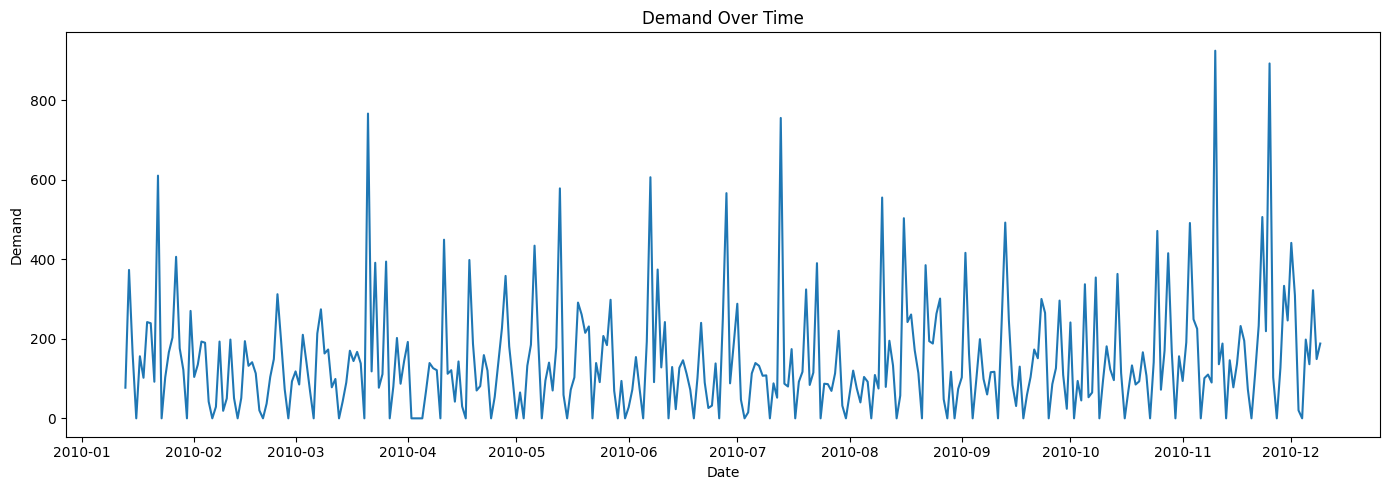

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(product_data['Date'], product_data['demand'])
plt.title('Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.tight_layout()
plt.show()

In [16]:
values = product_data['demand'].values.astype('float32').reshape(-1,1)

limit = int(len(values) * 0.8)

train = values[: limit]
test = values[limit: ]

print('Total observation:', len(values))
print('Train observation:', len(train))
print('Test observation:', len(test))

Total observation: 331
Train observation: 264
Test observation: 67


In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train)

test_context = np.concatenate((train[-28:], test))
test_scaled = scaler.transform(test_context)

print('test min and max', train_scaled.min(), train_scaled.max())
print('test_scaled min and max', test_scaled.min(), test_scaled.max())

test min and max 0.0 1.0
test_scaled min and max 0.0 1.2062663


In [18]:
LOOKBACK = 28
def create_sequence(values, lookback):
  X=[]
  y=[]
  for index in range(lookback, len(values)):
    X.append(values[index - lookback: index])
    y.append(values[index])
  return np.array(X), np.array(y)

In [31]:
X_train, y_train = create_sequence(train_scaled, LOOKBACK)
x_test, y_test = create_sequence(test_scaled, LOOKBACK)

print('X_train shape', X_train.shape)
print('X_test shape', X_test.shape)
print('y_train shape', y_train.shape)
print('y_test shape', y_test.shape)


X_train shape (236, 28, 1)
X_test shape (236, 1)
y_train shape (236, 1)
y_test shape (67, 1)


In [32]:
import tensorflow as tf

tf.random.set_seed(42)
np.random.seed(42)

def create_lstm_model(values):
  model = tf.keras.Sequential([
      tf.keras.layers.Input(shape=(LOOKBACK, 1)),
      tf.keras.layers.LSTM(32),
      tf.keras.layers.Dropout(0.2),
      tf.keras.layers.Dense(1)
  ])

  model.compile(optimizer='adam', loss='mse', metrics=['mae'])
  return model

model = create_lstm_model(values)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience = 5,
    restore_best_weights = True
)

In [34]:
history =model.fit(
    X_train, y_train, validation_data = (x_test, y_test),
    epochs = 50,
    batch_size = 32,
    callbacks = [early_stopping]
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0486 - mae: 0.1515 - val_loss: 0.0691 - val_mae: 0.1633
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0323 - mae: 0.1230 - val_loss: 0.0564 - val_mae: 0.1578
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0330 - mae: 0.1342 - val_loss: 0.0567 - val_mae: 0.1555
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0312 - mae: 0.1224 - val_loss: 0.0594 - val_mae: 0.1521
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0309 - mae: 0.1193 - val_loss: 0.0596 - val_mae: 0.1520
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0318 - mae: 0.1220 - val_loss: 0.0583 - val_mae: 0.1525
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0311 - mae: 0.1224 - val_loss: 0.0576 - val_mae: 0.1528


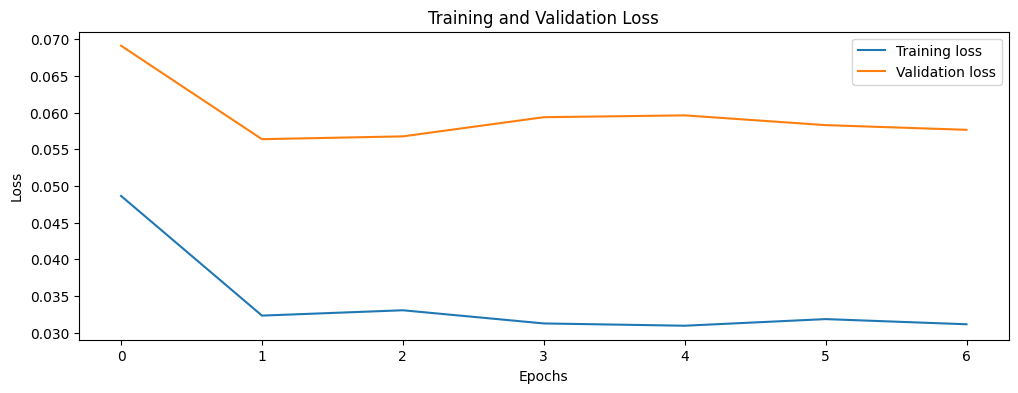

<Figure size 640x480 with 0 Axes>

In [35]:
plt.figure(figsize=(12,4))

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
plt.tight_layout()


In [38]:
model_scaled_prediction = model.predict(x_test)
model_prediction = scaler.inverse_transform(model_scaled_prediction)
actual_prediction = scaler.inverse_transform(y_test)

print('model prediction shape', model_prediction.shape)
print('actual prediction shape', actual_prediction.shape)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
model prediction shape (67, 1)
actual prediction shape (67, 1)


In [51]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(actual_prediction, model_prediction)
mae = mean_absolute_error(actual_prediction, model_prediction)

def calculate_mape(actual, predicted, epsilon=1e-8):
  denominator = np.maximum(np.abs(actual), epsilon)
  return np.mean(np.abs((actual - predicted) / denominator)) * 100

def calulcate_wape(actual, predicted, epsilon=1e-8):
  denominator = max(np.sum(np.abs(actual)), epsilon)
  return (np.sum(np.abs(actual - predicted)) / denominator) * 100

mape = calculate_mape(actual_prediction, model_prediction)
wape = calulcate_wape(actual_prediction, model_prediction)


print('MSE:', mse)
print('MAE:', mae)
print('MAPE', calculate_mape(actual_prediction, model_prediction))
print('WAPE', calulcate_wape(actual_prediction, model_prediction))

MSE: 33070.4765625
MAE: 120.84735870361328
MAPE 244368850000.0
WAPE 66.02604


In [52]:
modelfile = '/content/lstm_demand_model.keras'
model.save(modelfile)

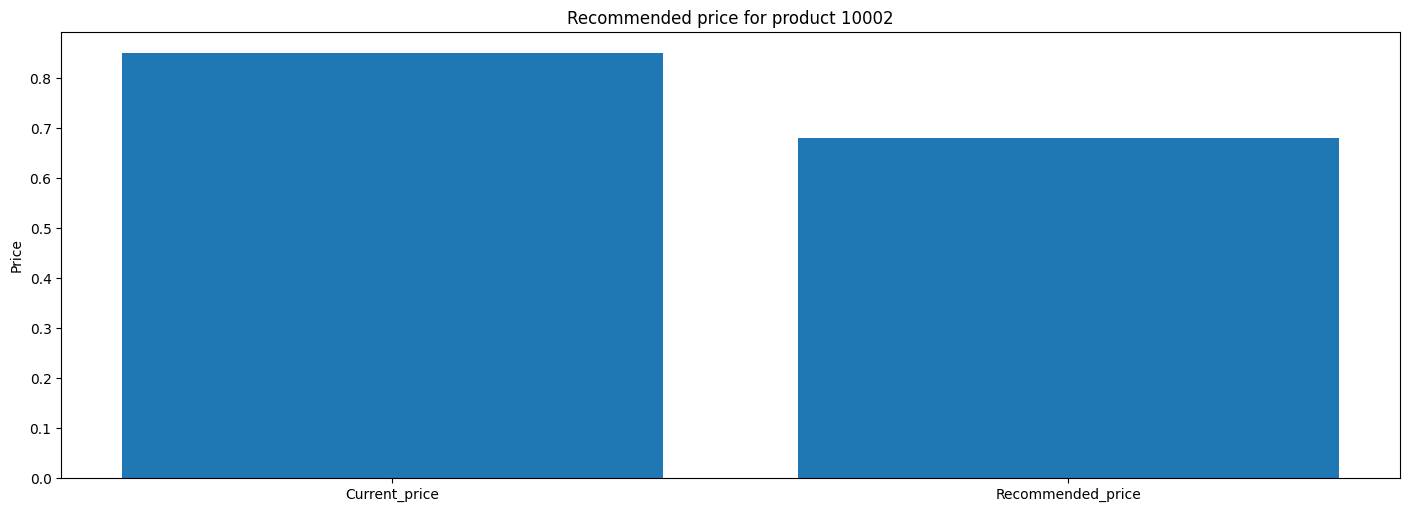

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv('../data/processed/pricing_recommendations.csv')

selected = data.iloc[0]

current_price = selected['current_price']
recommended_price = selected['recommended_price']

labels=['Current_price', 'Recommended_price']

values=[current_price, recommended_price]

plt.figure(figsize=(14,5))
plt.bar(labels, values)
plt.tight_layout()
plt.title(f"Recommended price for product "f"{selected['StockCode']}")
plt.ylabel('Price')
plt.show()